# Modelado Estocástico
## Clase 4 - Introducción a Regresión Múltiple

En la teoría analizamos el modelo con dos variables explicativas:
$$y_{i} = \alpha + \beta_{1}x_{1i} + \beta_{2}x_{2i} + u_{i}$$

A continuación vamos a hacer un análisis de un dataset de ejemplo y a realizar un desarrollo práctico de lo visto en clase. Aprovechando esta práctica se incorporarán algunos recursos de visualización y manipulación de dataframes.
  

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.api as sms
import seaborn as sns

Configuramos la visualización de hasta 6 decimales en Pandas para evitar la notación científica:

In [2]:
pd.set_option('display.float_format', '{:.6f}'.format)

### Carga de datos:

In [3]:
df_casa = pd.read_excel('Ejemplo_Casa.xls', sheet_name='HPRICE', usecols='A:L')
df_casa.head()

,PRECIO,LOTE,CUARTOS,BANOS,PISOS,ENTRADA,REC,SOTANO,CALEF,AIRE,GARAGE,NBHD
0,42000,5850,3,1,2,1,0,1,0,0,1,0
1,38500,4000,2,1,1,1,0,0,0,0,0,0
2,49500,3060,3,1,1,1,0,0,0,0,0,0
3,60500,6650,3,1,2,1,1,0,0,0,0,0
4,61000,6360,2,1,1,1,0,0,0,0,0,0


### Algunas generalidades sobre el dataset:

In [4]:
df_casa.describe()

,PRECIO,LOTE,CUARTOS,BANOS,PISOS,ENTRADA,REC,SOTANO,CALEF,AIRE,GARAGE,NBHD
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,68121.597070,5150.265568,2.965201,1.285714,1.807692,0.858974,0.177656,0.349817,0.045788,0.316850,0.692308,0.234432
std,26702.670926,2168.158725,0.737388,0.502158,0.868203,0.348367,0.382573,0.477349,0.209216,0.465675,0.861307,0.424032
min,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,49125.000000,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,62000.000000,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,190000.000000,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000


Encontramos:

- Variables continuas, como el `PRECIO` (el valor que nos gustaría poder estimar) y la dimensión del `LOTE`.
- Variables discretas, como los contadores de la cantidad de `CUARTOS`, `BANOS`, `PISOS` y `GARAGE`.
- Variables _dummy_, que toman valor 0 o valor 1, como `ENTRADA`, `REC`, `SOTANO`, `CALEF`, `AIRE` y `NBHD`.

#### Podemos graficar la relación entre estas variables y el precio para ver sus comportamientos de forma aislada:



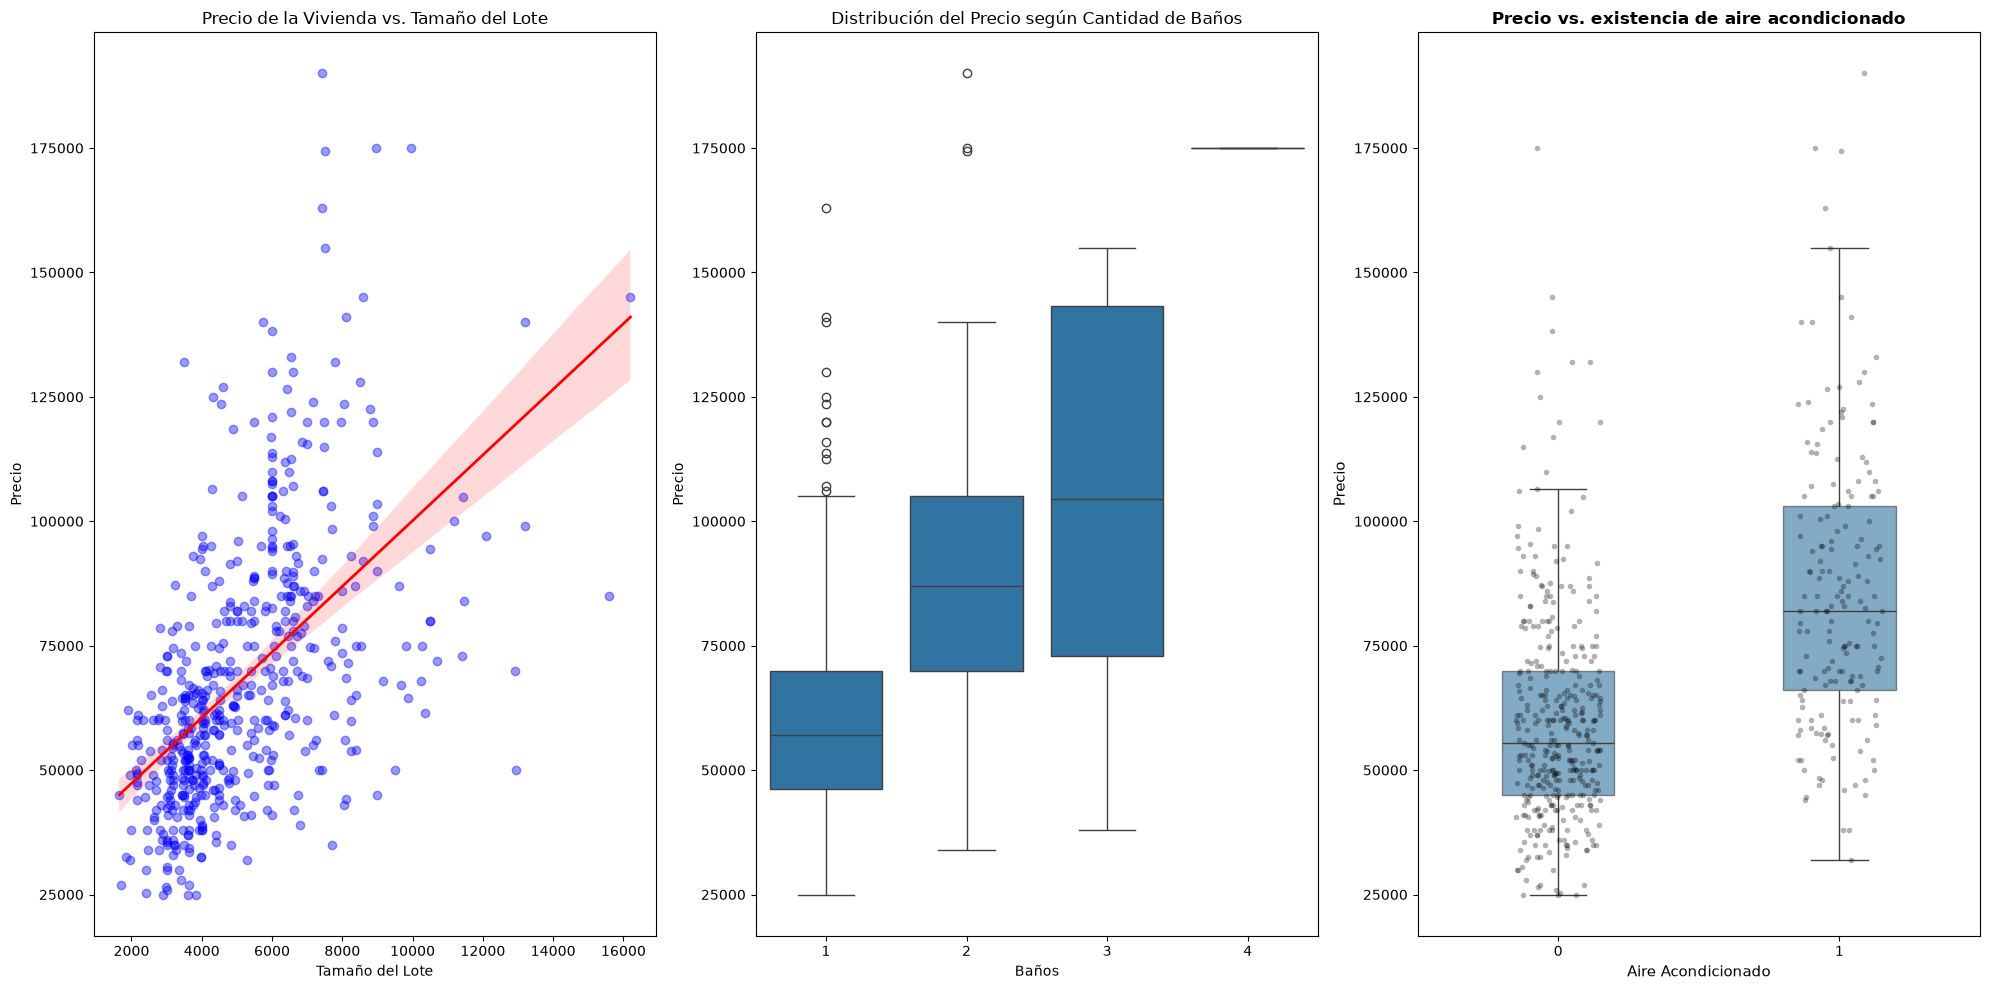

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0]
sns.regplot(data=df_casa, x='LOTE', y='PRECIO', color='b',
            scatter_kws={'alpha':0.4}, line_kws={'color':'red', 'lw':2}, ax=axes[0])
axes[0].set_title('Precio de la Vivienda vs. Tamaño del Lote')
axes[0].set_xlabel('Tamaño del Lote')
axes[0].set_ylabel('Precio')

sns.boxplot(data=df_casa, x='BANOS', y='PRECIO', ax=axes[1])
axes[1].set_title('Distribución del Precio según Cantidad de Baños')
axes[1].set_xlabel('Baños')
axes[1].set_ylabel('Precio')

sns.boxplot(
    data=df_casa, x='AIRE', y='PRECIO', ax=axes[2], width=0.4, showfliers=False, boxprops=dict(alpha=0.6)
)
sns.stripplot(
    data=df_casa, x='AIRE', y='PRECIO', ax=axes[2],
    color='black', alpha=0.3, size=4, jitter=0.15
)

axes[2].set_title('Precio vs. existencia de aire acondicionado', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Aire Acondicionado', fontsize=11)
axes[2].set_ylabel('Precio', fontsize=11)

plt.tight_layout()
plt.show()

Observación: En la tercera figura agregamos una dispersión para que los valores (que solo valen 0 - Sin Aire y 1 - Con Aire en el eje x) no se superpongan en una línea que a la vista puede ser muy densa y poco ilustrativa. Es "ruido" introducido intencionalmente con el parámetro `jitter`.

### Regresión Múltiple



Generamos `y` y `X`, separando los PRECIOS de los valores restantes (y sumando la columna de constantes con unos) para el cálculo del modelo de regresión múltiple:

In [6]:
variables = ['LOTE', 'CUARTOS', 'BANOS', 'PISOS', 'ENTRADA', 'REC',
       'SOTANO', 'CALEF', 'AIRE', 'GARAGE', 'NBHD']
X = sm.add_constant(df_casa[variables])
y = df_casa['PRECIO']
regmul = sm.OLS(y, X).fit()
print(regmul.summary())


                            OLS Regression Results                            
Dep. Variable:                 PRECIO   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     99.97
Date:                Sat, 18 Jul 2026   Prob (F-statistic):          6.18e-122
Time:                        12:11:08   Log-Likelihood:                -6034.1
No. Observations:                 546   AIC:                         1.209e+04
Df Residuals:                     534   BIC:                         1.214e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4038.3504   3409.471     -1.184      0.2

In [7]:
intercepto = regmul.params['const']
pendiente_LOTE = regmul.params['LOTE']
regmul.params


const     -4038.350425
LOTE          3.546303
CUARTOS    1832.003466
BANOS     14335.558468
PISOS      6556.945711
ENTRADA    6687.778890
REC        4511.283826
SOTANO     5452.385539
CALEF     12831.406266
AIRE      12632.890405
GARAGE     4244.829004
NBHD       9369.513239
dtype: float64

### Descomposición de la suma de cuadrados

$
\text{RSS} = \text{TSS} - \text{ESS}
$

In [8]:
tss = regmul.centered_tss
ess = regmul.ess
rss = regmul.ssr
print(f"TSS: {tss} \nESS: {ess} \nRSS: {rss} \nSuma ESS+RSS = {ess + rss}")

TSS: 388602785841.3553 
ESS: 261577714196.88733 
RSS: 127025071644.46797 
Suma ESS+RSS = 388602785841.3553


### $R^2$

In [9]:
r2 = regmul.rsquared
r2_calculado = ess/tss
r2_calculado2 = 1 - rss/tss
print(f"R^2: {r2} \nR^2 calculado: {r2_calculado} \nR^2 calculado2: {r2_calculado2}")

R^2: 0.6731236206414506 
R^2 calculado: 0.6731236206414507 
R^2 calculado2: 0.6731236206414506


### Estimador $s^2$ del parámetro $\sigma^2$


In [10]:
s2 = regmul.scale
print(s2)

237874666.00087634


In [11]:
s2_manual = rss/regmul.df_resid
print(s2_manual)

237874666.00087634


Solemos usar la raiz cuadrada de este estadistico, i.e., el desvio estandar estimado de los errores, es decir, el estimador de $\sigma$:

In [12]:
s2 ** 0.5

np.float64(15423.185987365787)

Podemos verificar que la suma de los residuos es (aproximadamente) cero

In [13]:
regmul.resid.sum()

np.float64(2.287561073899269e-08)

Comparamos el producto punto entre variables explicativas y los residuos. La primera variable, correspondiente a la dimensión del lote es continua y de una escala desproporcionada al resto, por eso su valor es el más lejano a cero. Acá estamos verificando que se cumplen las ecuaciones normales (CPO del problema de minimización)

In [14]:
print(np.dot(regmul.model.exog[:, 1], regmul.resid))
print(np.dot(regmul.model.exog[:, 2], regmul.resid))
print(np.dot(regmul.model.exog[:, 3], regmul.resid))

0.00014196382835507393
6.283516995608807e-08
2.5938788894563913e-08


Matriz de varianzas y Covarianzas de los beta_sombrero  𝛽̂

In [15]:
var_beta = regmul.cov_params()
var_beta

,const,LOTE,CUARTOS,BANOS,PISOS,ENTRADA,REC,SOTANO,CALEF,AIRE,GARAGE,NBHD
const,11624494.546150,-296.945417,-2118816.883645,-911313.431730,-87428.173732,-2942239.344281,426540.971582,-421071.086757,61976.076750,475767.705254,388321.207172,551878.232222
LOTE,-296.945417,0.122710,-29.661377,-52.711388,23.885865,-148.974939,-58.324760,43.384297,8.438617,-72.117711,-78.733884,-95.445621
CUARTOS,-2118816.883645,-29.661377,1096209.460784,-352197.546618,-342177.850510,256197.297230,42408.414769,-235829.671338,-70629.115254,16137.159980,-66115.089126,-37257.289434
BANOS,-911313.431730,-52.711388,-352197.546618,2219864.145088,-284899.529470,126616.008185,-134465.104128,-223758.509764,-275816.040849,-113353.362856,-119278.039737,53544.356480
PISOS,-87428.173732,23.885865,-342177.850510,-284899.529470,856161.410032,-277224.684123,-104624.772615,407996.929689,-98435.326481,-356482.503681,58408.701392,-48318.841960
ENTRADA,-2942239.344281,-148.974939,256197.297230,126616.008185,-277224.684123,4183030.502175,-127372.640417,-91923.450851,39777.814634,15552.536381,-220766.215495,-443940.392501
REC,426540.971582,-58.324760,42408.414769,-134465.104128,-104624.772615,-127372.640417,3609839.228295,-1055397.264502,-6500.438129,-218557.626535,70135.578088,-134793.894058
SOTANO,-421071.086757,43.384297,-235829.671338,-223758.509764,407996.929689,-91923.450851,-1055397.264502,2521819.905361,-85392.579487,-102859.460534,-19948.961281,-504779.689456
CALEF,61976.076750,8.438617,-70629.115254,-275816.040849,-98435.326481,39777.814634,-6500.438129,-85392.579487,10352930.850140,758139.982571,-215636.860773,291971.351560
AIRE,475767.705254,-72.117711,16137.159980,-113353.362856,-356482.503681,15552.536381,-218557.626535,-102859.460534,758139.982571,2418090.511097,-118591.916832,-82640.591301


Por ejemplo, el cruce entre `CUARTOS` y `NBHD`:

In [16]:
regmul.cov_params().loc['CUARTOS','NBHD']

np.float64(-37257.28943368899)

### P-valores

In [17]:
regmul.pvalues

const     0.236762
LOTE      0.000000
CUARTOS   0.080733
BANOS     0.000000
PISOS     0.000000
ENTRADA   0.001145
REC       0.017929
SOTANO    0.000642
CALEF     0.000076
AIRE      0.000000
GARAGE    0.000001
NBHD      0.000000
dtype: float64

### Intervalos de confianza

In [18]:
regmul.conf_int(alpha=0.05)

,0,1
const,-10735.971609,2659.270758
LOTE,2.858168,4.234438
CUARTOS,-224.740890,3888.747822
BANOS,11408.733579,17262.383357
PISOS,4739.291087,8374.600336
ENTRADA,2670.064534,10705.493247
REC,778.975864,8243.591788
SOTANO,2332.845419,8571.925660
CALEF,6510.705975,19152.106558
AIRE,9578.181593,15687.599216


#### Intervalo de confianza del 95% para $\beta_{LOTE}$

In [19]:
print(regmul.conf_int(alpha=0.05).loc["LOTE"])

0   2.858168
1   4.234438
Name: LOTE, dtype: float64


### Realizamos el Test t para $H_0: \beta_{\text{AIRE}} = 10000$

Hay dos sintaxis posibles:

In [20]:
print(regmul.t_test("AIRE = 10000"))

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0          1.263e+04   1555.021      1.693      0.091    9578.182    1.57e+04


Indicando por parámetro la posición de la variable en X y el valor al que se lo iguala en el test.

In [21]:
print(regmul.t_test(([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], 10000)))

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0          1.263e+04   1555.021      1.693      0.091    9578.182    1.57e+04


Equivalentemente, se puede obtener la posición y simplificar el parámetro:

In [22]:
R = np.zeros((1, len(regmul.params)))
R[0, regmul.params.index.get_loc("AIRE")] = 1

print(regmul.t_test((R, [10000])))

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0          1.263e+04   1555.021      1.693      0.091    9578.182    1.57e+04


In [23]:
print(regmul.conf_int(alpha=0.05).loc["LOTE"])

0   2.858168
1   4.234438
Name: LOTE, dtype: float64


### Realizamos el Test F para

$H_0: \text{CALEF} = 0 \text{ y AIRE} = 0$

In [24]:
print(regmul.f_test("CALEF = 0, AIRE = 0"))

<F test: F=36.88875086741614, p=9.856033740437303e-16, df_denom=534, df_num=2>


Equivalentemente:

In [25]:
R = np.zeros((2, len(regmul.params)))
R[0, regmul.params.index.get_loc("AIRE")] = 1
R[1, regmul.params.index.get_loc("CALEF")] = 1

print(regmul.f_test((R, [0,0])))

<F test: F=36.88875086741614, p=9.856033740437303e-16, df_denom=534, df_num=2>


## Fitted values y Residuos

###  Corroboramos que $$R^2 = (corr(y,\hat{y})^2)$$

In [26]:
y_hat = regmul.fittedvalues
np.corrcoef(y, y_hat)[0, 1]** 2

np.float64(0.6731236206414501)

In [27]:
regmul.rsquared

np.float64(0.6731236206414506)

### $R^2$ ajustado

In [28]:
regmul.rsquared_adj

np.float64(0.6663902120778851)

Manualmente:

In [29]:
1 - (regmul.ssr / regmul.df_resid) / (regmul.centered_tss / (regmul.df_model + regmul.df_resid))

np.float64(0.6663902120778851)

### Gráfico:

$\hat{y}$ y resid tienen correlación CERO

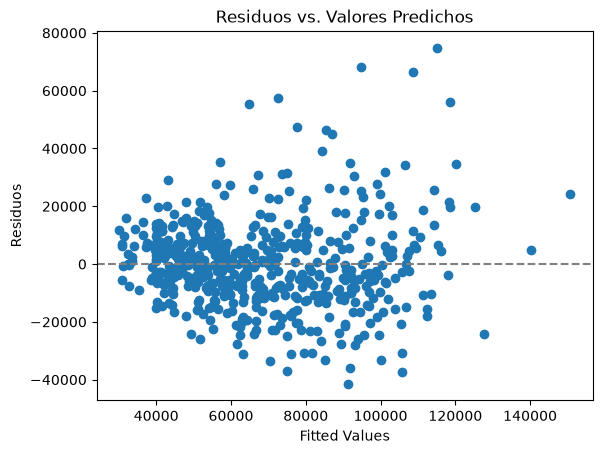

In [30]:
plt.scatter(regmul.fittedvalues, regmul.resid)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuos")
plt.title("Residuos vs. Valores Predichos")
plt.show()

## Banda de Confianza y de Prediccion

Intervalo de confianza para $\hat{Y}$ (Banda de confianza)

Intervalo de confianza para $Y$ (Banda de predicción)

In [31]:
predc = regmul.get_prediction()
IC_predc = predc.summary_frame(alpha = 0.05)
IC_predc.head()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,66037.975672,1790.507321,62520.673808,69555.277537,35536.935009,96539.016336
1,41391.151457,1406.499937,38628.199977,44154.102936,10967.871390,71814.431524
2,39889.630131,1534.101619,36876.015820,42903.244441,9442.562285,70336.697976
3,63689.087331,2262.055723,59245.468074,68132.706588,33067.398591,94310.776070
4,49760.426466,1567.689375,46680.831819,52840.021113,19306.757191,80214.095742


Bandas de confianza y prediccion para un valor especifico: la media de c/u

In [32]:
media_variables = pd.DataFrame(
    [[1] + df_casa[regmul.model.exog_names[1:]].mean().tolist()],
    columns=regmul.model.exog_names
)
media_variables

,const,LOTE,CUARTOS,BANOS,PISOS,ENTRADA,REC,SOTANO,CALEF,AIRE,GARAGE,NBHD
0,1,5150.265568,2.965201,1.285714,1.807692,0.858974,0.177656,0.349817,0.045788,0.316850,0.692308,0.234432


In [33]:
pred_media = regmul.get_prediction(media_variables)
IC_media = pred_media.summary_frame(alpha=0.05)
IC_media

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,68121.597070,660.051427,66824.981251,69418.212888,37796.305946,98446.888193


Bandas para un valor específico

In [34]:
valores = pd.DataFrame([[1, 5000, 4, 2, 2, 1, 1, 1, 1, 1, 2, 0]], columns=regmul.model.exog_names)
pred = regmul.get_prediction(valores)
summary = pred.summary_frame(alpha=0.05)
print(summary)

           mean     mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0 113411.589583 3852.264663  105844.137876  120979.041291  82183.262787   

   obs_ci_upper  
0 144639.916380  


# Interacciones:




> _"Suponga que usted quiere saber si un pie cuadrado más de LOTE se valora de la misma manera si la casa queda en un vecindario agradable
(NBHD = 1) que cuando no está en un vecindario agradable (NBHD = 0). Uno puede crear una nueva variable explicativa que sea el producto o interacción entre LOTE y NBHD. E incorporarla como otra variable explicativa."_

In [35]:
X_prod = df_casa.drop(columns=['PRECIO'])
X_prod['LOTE_NBHD'] = X_prod['LOTE'] * X_prod['NBHD']
X_prod = sm.add_constant(X_prod)
print(sm.OLS(df_casa['PRECIO'], X_prod).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                 PRECIO   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     92.19
Date:                Sat, 18 Jul 2026   Prob (F-statistic):          1.55e-121
Time:                        12:11:09   Log-Likelihood:                -6032.6
No. Observations:                 546   AIC:                         1.209e+04
Df Residuals:                     533   BIC:                         1.215e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2899.3158   3469.795     -0.836      0.4

En cambio, si usamos smf (statsmodels.formula) el uso de interacciones resulta mucho más simple; los operadores de las interacciones representan:

- `x1:x2` incluye solo la interacción pura entre `x1` y `x2`.

- `x1*x2` incluye `x1`, `x2` y `x1:x2` (interacción)

- `x1 + x2` incluye efectos principales de `x1` y `x2`.

Entonces si hacemos la regresión con `LOTE + CUARTOS + LOTE:NBHD`

`PRECIO` será la variable dependiente y `LOTE + CUARTOS` los efectos de esas variables junto a los de `LOTE:NBHD`, que es la interacción pura de `LOTE` y `NBHD`. Veamos sus resultados y comparemos sm y smf:

In [36]:
regpura = sm.OLS(df_casa['PRECIO'],X_prod[['const','LOTE','CUARTOS','LOTE_NBHD']]).fit()
print(regpura.summary())

                            OLS Regression Results                            
Dep. Variable:                 PRECIO   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     123.6
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           5.15e-61
Time:                        12:11:09   Log-Likelihood:                -6197.0
No. Observations:                 546   AIC:                         1.240e+04
Df Residuals:                     542   BIC:                         1.242e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9043.5973   4032.019      2.243      0.0

In [37]:
print(regpura.f_test('LOTE_NBHD = 0'))

<F test: F=32.89254279344006, p=1.6200080563575785e-08, df_denom=542, df_num=1>


La fórmula `CUARTOS + LOTE * NBHD` incorpora el operador * en `LOTE * NBHD`, que significa las variables y las interacciones.

In [38]:
regprod = sm.OLS(df_casa['PRECIO'],X_prod[['const','CUARTOS','LOTE','NBHD','LOTE_NBHD']]).fit()
print(regprod.summary())


                            OLS Regression Results                            
Dep. Variable:                 PRECIO   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     93.70
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           1.62e-60
Time:                        12:11:09   Log-Likelihood:                -6195.6
No. Observations:                 546   AIC:                         1.240e+04
Df Residuals:                     541   BIC:                         1.242e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7294.7262   4163.014      1.752      0.0

In [39]:
print(regprod.f_test('NBHD=0 , LOTE_NBHD = 0'))

<F test: F=17.857908123948647, p=3.0879947302151524e-08, df_denom=541, df_num=2>


In [40]:
regprod1 = smf.ols('PRECIO ~  CUARTOS + LOTE*NBHD ', data= df_casa).fit()
print(regprod1.summary())


                            OLS Regression Results                            
Dep. Variable:                 PRECIO   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     93.70
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           1.62e-60
Time:                        12:11:09   Log-Likelihood:                -6195.6
No. Observations:                 546   AIC:                         1.240e+04
Df Residuals:                     541   BIC:                         1.242e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   7294.7262   4163.014      1.752      0.0

In [41]:
print(regprod1.f_test('NBHD=0 , LOTE:NBHD = 0'))

<F test: F=17.857908123948647, p=3.0879947302151524e-08, df_denom=541, df_num=2>


Para una interacción con la fórmula `LOTE*CUARTOS*BANOS*NBHD` sería necesario generar todos los productos dos a dos, tres a tres y el de las cuatro variables.
Si no se desea generar las variables extra de todas las combinaciones, se puede utilizar la notación de `R` con `smf.ols`:

In [42]:
regprod2 = smf.ols('PRECIO ~  LOTE*CUARTOS*BANOS*NBHD ', data= df_casa).fit()
print(regprod2.summary())

                            OLS Regression Results                            
Dep. Variable:                 PRECIO   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     43.95
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           7.00e-83
Time:                        12:11:09   Log-Likelihood:                -6118.7
No. Observations:                 546   AIC:                         1.227e+04
Df Residuals:                     530   BIC:                         1.234e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                4

## Casas con al menos 4 baños:

In [43]:
df_casa[df_casa["BANOS"] >= 4]

,PRECIO,LOTE,CUARTOS,BANOS,PISOS,ENTRADA,REC,SOTANO,CALEF,AIRE,GARAGE,NBHD
331,175000,8960,4,4,4,1,0,0,0,1,3,0


En este caso hay exactamente una, la quitamos de la muestra:

In [44]:
df_filtrado = df_casa[df_casa["BANOS"] != 4].copy()
df_filtrado.BANOS.value_counts()

BANOS
1    402
2    133
3     10
Name: count, dtype: int64

Volvemos a correr el modelo, pero sin considerar la fila de la casa de 4 baños al momento de armar `y1` y `X1`

In [45]:
y1 = df_filtrado['PRECIO']
X1 = sm.add_constant(df_filtrado.drop(columns='PRECIO'))
regMenos4 = sm.OLS(y1, X1).fit()
print(regMenos4.summary())

                            OLS Regression Results                            
Dep. Variable:                 PRECIO   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     96.14
Date:                Sat, 18 Jul 2026   Prob (F-statistic):          7.67e-119
Time:                        12:11:09   Log-Likelihood:                -6022.2
No. Observations:                 545   AIC:                         1.207e+04
Df Residuals:                     533   BIC:                         1.212e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3509.7393   3419.390     -1.026      0.3

### Creamos _dummies_

Vamos a conservar los casos que tengan exactamente dos o tres baños, convirtiendo esa cantidad discreta en variables booleanas para cada valor posible.

Utilizamos [`pandas.get_dummies`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html). Su parámetro `drop_first` en `True` nos permite quitar el primer nivel de la variable categórica (se correspondería con 1 solo baño), en `False` mantendría las columnas para 1, 2 y 3 baños. El parámetro `dtype` nos permite especificar el tipo de la conversión (`bool` por defecto, pero podría ser `float` o, como en este caso, enteros).

In [46]:
X2 = pd.get_dummies(df_filtrado, columns=['BANOS'], drop_first=True, dtype=int)
X2.head()

,PRECIO,LOTE,CUARTOS,PISOS,ENTRADA,REC,SOTANO,CALEF,AIRE,GARAGE,NBHD,BANOS_2,BANOS_3
0,42000,5850,3,2,1,0,1,0,0,1,0,0,0
1,38500,4000,2,1,1,0,0,0,0,0,0,0,0
2,49500,3060,3,1,1,0,0,0,0,0,0,0,0
3,60500,6650,3,2,1,1,0,0,0,0,0,0,0
4,61000,6360,2,1,1,0,0,0,0,0,0,0,0


- Construyo un nuevo `X2`, incluyendo la columna de unos para el intercepto y sin el Precio (`y1`).

Corremos nuevamente el modelo con las variables dummies creadas:

In [47]:
X2 = sm.add_constant(X2.drop(columns=['PRECIO']))
regdummy = sm.OLS(y1, X2).fit()
print(regdummy.summary())

                            OLS Regression Results                            
Dep. Variable:                 PRECIO   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     88.01
Date:                Sat, 18 Jul 2026   Prob (F-statistic):          7.04e-118
Time:                        12:11:09   Log-Likelihood:                -6022.1
No. Observations:                 545   AIC:                         1.207e+04
Df Residuals:                     532   BIC:                         1.213e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.031e+04   3464.573      2.976      0.0

Vamos a combinar los parámetros que nos interesan para realizar un F-Test

In [48]:
regdummy.params[['BANOS_2','BANOS_3']]

BANOS_2   13481.181977
BANOS_3   29392.540176
dtype: float64

Con notación de dataframe, lo que hacemos es escribir en modo vector el valor de las constantes de cada parámetro a través de una equivalencia algebraica.

La hipótesis `BANOS_3` = 2 $\cdot$ `BANOS_2` se reescribe algebraicamente como `BANOS_3` - 2 $\cdot$ `BANOS_2`=0, generando un vector con ceros en todas las posiciones excepto en la de `BANOS_3`, que será 1 y en `BANOS_2` que será -2.

In [49]:
r_matrix = np.zeros(X2.shape[1])

r_matrix[X2.columns.get_loc("BANOS_3")] = 1
r_matrix[X2.columns.get_loc("BANOS_2")] = -2

print(regdummy.f_test(r_matrix))

<F test: F=0.18151291728592503, p=0.6702485908495185, df_denom=532, df_num=1>


O, equivalentemente:

In [50]:
print(regdummy.f_test("BANOS_3 = 2 * BANOS_2"))

<F test: F=0.18151291728592503, p=0.6702485908495185, df_denom=532, df_num=1>
